# Large-Scale Binary Equilibrium: Au-Bi

65,000 independent point equilibria over the Au-Bi system (database from
J. Wang et al., *J. Electron. Mater.* **36**, 568 (2007)) — a dense 260 x 250
composition-temperature grid of the kind used for phase diagram mapping,
property databases, or data-set generation.

The reference solver takes about a minute on this workload; the accelerated
backend runs the identical problem in a few seconds on one CPU core (or a GPU
with `BACKEND = 'gpu'`).

In [1]:
import time
import warnings
import numpy as np
import matplotlib.pyplot as plt
import pycalphad
from pycalphad import Database, Workspace, calculate, equilibrium, variables as v

# The backend to demonstrate: 'c++' runs generated kernels on the CPU,
# 'gpu' runs the same kernels through CuPy on an NVIDIA or AMD GPU.
BACKEND = 'c++'

def timed(label, fn):
    """Run fn(), print and return (result, elapsed seconds)."""
    start = time.perf_counter()
    result = fn()
    elapsed = time.perf_counter() - start
    print(f'{label}: {elapsed:.1f} s')
    return result, elapsed


In [2]:
dbf = Database('../databases/AuBi-07Wan.tdb')
comps = ['AU', 'BI', 'VA']
phases = sorted(dbf.phases.keys())
nx, nt = 260, 250
conditions = {v.N: 1, v.P: 101325,
              v.X('BI'): (0.02, 0.981, 0.96 / (nx - 1)),
              v.T: (450, 1000.1, 550.0 / (nt - 1))}
print(f'phases: {phases}')
print(f'conditions: {nx} compositions x {nt} temperatures = {nx * nt} equilibria')

phases: ['AU2BI_C15', 'BCC_A2', 'FCC_A1', 'HCP_A3', 'LIQUID', 'RHOMBOHEDRAL_A7']
conditions: 260 compositions x 250 temperatures = 65000 equilibria


In [3]:
# Warm the kernel cache (compilation happens once per system, then is reused).
with pycalphad.backend(BACKEND):
    equilibrium(dbf, comps, phases, {v.N: 1, v.P: 101325, v.T: 700, v.X('BI'): 0.5});

## Reference solver

This cell takes about a minute.

In [4]:
ref, t_ref = timed('reference solver   ', lambda: equilibrium(dbf, comps, phases, conditions))

reference solver   : 55.1 s


## Accelerated backend — the identical calculation

In [5]:
with pycalphad.backend(BACKEND):
    acc, t_acc = timed('accelerated backend', lambda: equilibrium(dbf, comps, phases, conditions))

print(f'speedup: {t_ref / t_acc:.1f}x')

accelerated backend: 6.8 s
speedup: 8.1x


## Agreement

In [6]:
def compare_results(ref, acc):
    """Agreement report between a reference and an accelerated result."""
    gm_ref = np.asarray(ref.GM.values, dtype=float).reshape(-1)
    gm_acc = np.asarray(acc.GM.values, dtype=float).reshape(-1)
    both = ~np.isnan(gm_ref) & ~np.isnan(gm_acc)
    print(f'conditions: {gm_ref.size}   converged: reference {int((~np.isnan(gm_ref)).sum())}, '
          f'accelerated {int((~np.isnan(gm_acc)).sum())}')
    dgm = np.abs(gm_acc[both] - gm_ref[both])
    print(f'max |dGM| over co-converged conditions: {dgm.max():.3e} J/mol '
          f'(relative: {(dgm / np.abs(gm_ref[both])).max():.3e})')
    ph_ref = np.asarray(ref.Phase.values).reshape(-1, ref.Phase.values.shape[-1])
    ph_acc = np.asarray(acc.Phase.values).reshape(-1, acc.Phase.values.shape[-1])
    mismatched = sum(sorted(p for p in ph_ref[i] if p) != sorted(p for p in ph_acc[i] if p)
                     for i in np.flatnonzero(both))
    print(f'stable-phase-set mismatches: {mismatched} of {int(both.sum())}')


In [7]:
compare_results(ref, acc)

conditions: 65000   converged: reference 64999, accelerated 65000
max |dGM| over co-converged conditions: 3.379e-05 J/mol (relative: 8.932e-10)
stable-phase-set mismatches: 0 of 64999


## The phase diagram, read off the accelerated result

Every grid point carries its stable phase set, so the phase diagram is a
scatter of the grid colored by stable phases.

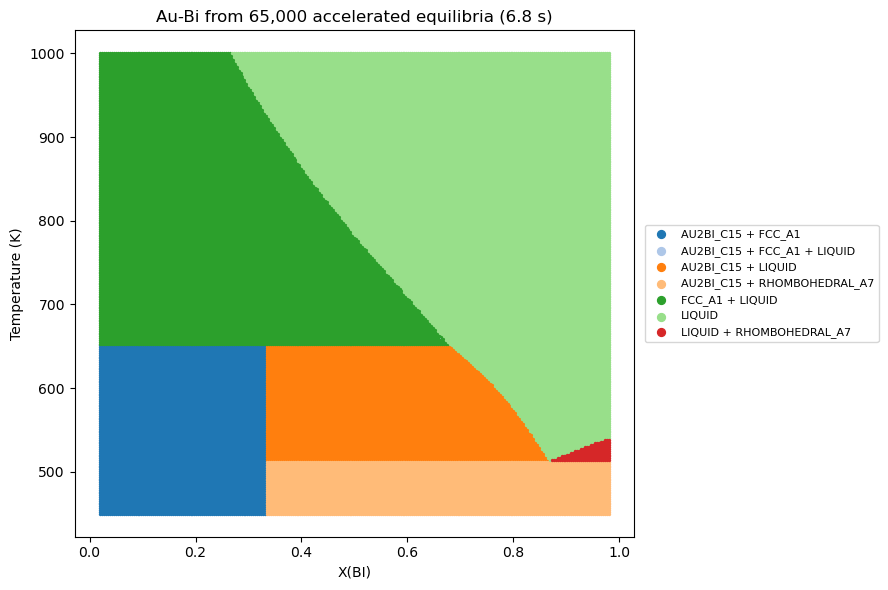

In [8]:
ph = np.asarray(acc.Phase.values).squeeze()          # (T, X_BI, vertex)
T_grid, X_grid = np.meshgrid(acc.coords['T'].values, acc.coords['X_BI'].values, indexing='ij')
labels = np.array([' + '.join(sorted(set(row) - {''})) for row in ph.reshape(-1, ph.shape[-1])])

fig, ax = plt.subplots(figsize=(9, 6))
for i, lab in enumerate(sorted(set(labels) - {''})):
    m = labels == lab
    ax.scatter(X_grid.reshape(-1)[m], T_grid.reshape(-1)[m], s=2, label=lab,
               color=plt.cm.tab20(i % 20))
ax.set_xlabel('X(BI)'); ax.set_ylabel('Temperature (K)')
ax.set_title(f'Au-Bi from {nx * nt:,} accelerated equilibria ({t_acc:.1f} s)')
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=8, markerscale=4)
plt.tight_layout()